In [3]:
target_cols = 'K_incl'
input_folder=f'C:/Users/1/projects/zadachi/3 задача/{target_cols} determ'
output_file=f'{target_cols} determ.csv'

columns = ['K_Nu', 'K_E', 'K_Rho', 'K_incl', 'F', 'K_lambda_r', 'A2', 'А2_surface',  'Nu_host medium', 'E', 'Rho', 'Vp', 'Vs', 'Z']

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv(output_file)

# Подготовка данных
y = df[target_cols]
X = df[['A2', 'А2_surface']]


In [5]:
df

,K_Nu,K_E,K_Rho,K_incl,F,K_lambda_r,A2,А2_surface,Nu_host medium,E,Rho,Vp,Vs,Z
0,1,1,1,0.1000,0.1,10.000000,5.331341e-13,5.331372e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446
1,1,1,1,0.1000,0.2,5.000000,5.334827e-13,5.331472e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446
2,1,1,1,0.1000,0.3,3.333333,5.367524e-13,5.364047e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446
3,1,1,1,0.1000,0.4,2.500000,5.330409e-13,5.333102e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446
4,1,1,1,0.1000,0.5,2.000000,5.331411e-13,5.331653e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100095,1,1,1,0.9991,9.6,0.104167,5.323251e-13,5.341700e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446
100096,1,1,1,0.9991,9.7,0.103093,5.324428e-13,5.342459e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446
100097,1,1,1,0.9991,9.8,0.102041,5.325628e-13,5.343239e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446
100098,1,1,1,0.9991,9.9,0.101010,5.326846e-13,5.344037e-13,0.25,5.000000e+10,2700,4714.045208,2721.65527,2502.294446


In [6]:
def create_and_train_model(X_train, y_train, X_test, y_test, sample_size):
    """Создает и обучает модель на данных заданного размера"""
    
    scaler_X = StandardScaler()
    
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    # Создание модели
    model = Sequential([
        Dense(128, activation='relu', input_shape=(2,), name='hidden_layer_1'),
        Dropout(0.2),  # Добавляем Dropout для регуляризации
        Dense(64, activation='relu', name='hidden_layer_2'),
        Dropout(0.2),
        Dense(1, name='output_layer')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    # Ранняя остановка
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    )
    
    # Обучение
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=min(32, len(X_train)//10),
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Предсказание
    y_pred = np.array(model.predict(X_test_scaled)).flatten()
    y_test = np.array(y_test)
    
    # Метрики
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Относительная ошибка
    relative_errors = np.abs((y_test - y_pred) / y_test) * 100
    mean_relative_error = np.mean(relative_errors)
    std_relative_error = np.std(relative_errors)
    
    return {
        'sample_size': sample_size,
        'mse': mse,
        'mae': mae,
        'mape': mape,
        'rmse': rmse,
        'r2': r2,
        'mean_rel_error': mean_relative_error,
        'std_rel_error': std_relative_error,
        'accuracy': 100 - mean_relative_error,
        'history': history.history
    }

# Основной анализ
print("="*70)
print("АНАЛИЗ ВЛИЯНИЯ КОЛИЧЕСТВА ДАННЫХ НА КАЧЕСТВО ПРЕДСКАЗАНИЯ K_E")
print("="*70)

# Размеры выборок для анализа
sample_sizes = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
n_repetitions = 3  # Количество повторений для каждого размера (для усреднения)

results = []

# Фиксируем тестовую выборку (20% от всех данных)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

АНАЛИЗ ВЛИЯНИЯ КОЛИЧЕСТВА ДАННЫХ НА КАЧЕСТВО ПРЕДСКАЗАНИЯ K_E


In [7]:

print(f"\nТестовая выборка фиксирована: {len(X_test)} образцов")
print(f"Обучающая выборка (полная): {len(X_train_full)} образцов")
print("\n" + "-"*70)

for size in sample_sizes:
    print(f"\nАнализ для размера выборки: {size}")
    
    size_results = []
    
    for rep in range(n_repetitions):
        # Случайно выбираем size образцов из обучающей выборки
        indices = np.random.choice(len(X_train_full), size=min(size, len(X_train_full)), replace=False)
        X_train_sample = X_train_full.iloc[indices]
        y_train_sample = y_train_full.iloc[indices]
        
        # Обучаем и оцениваем модель
        result = create_and_train_model(
            X_train_sample, y_train_sample,
            X_test, y_test,
            size
        )
        size_results.append(result)
        
        print(f"  Повторение {rep+1}/{n_repetitions}: "
              f"Точность = {result['accuracy']:.2f}%")
    
    # Усредняем результаты по повторениям
    avg_result = {
        'sample_size': size,
        'mse': np.mean([r['mse'] for r in size_results]),
        'mae': np.mean([r['mae'] for r in size_results]),
        'mape': np.mean([r['mape'] for r in size_results]),
        'rmse': np.mean([r['rmse'] for r in size_results]),
        'r2': np.mean([r['r2'] for r in size_results]),
        'mean_rel_error': np.mean([r['mean_rel_error'] for r in size_results]),
        'std_rel_error': np.mean([r['std_rel_error'] for r in size_results]),
        'accuracy': np.mean([r['accuracy'] for r in size_results]),
        'accuracy_std': np.std([r['accuracy'] for r in size_results])
    }
    
    results.append(avg_result)
    
    print(f"\n  СРЕДНЕЕ для размера {size}:")
    print(f"    Точность: {avg_result['accuracy']:.2f}% ± {avg_result['accuracy_std']:.2f}%")
    print(f"    R²: {avg_result['r2']:.4f}")
    print(f"    RMSE: {avg_result['rmse']:.6f}")
    print(f"    MAE: {avg_result['mae']:.6f}")
    print(f"    MAPE: {avg_result['mape']:.6f}")

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)
results_df.to_csv(f'{target_cols} size result.csv', index=False)
print('Датасет сохранен')


Тестовая выборка фиксирована: 20020 образцов
Обучающая выборка (полная): 80080 образцов

----------------------------------------------------------------------

Анализ для размера выборки: 100
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Повторение 1/3: Точность = 30.78%
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Повторение 2/3: Точность = 32.94%
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Повторение 3/3: Точность = 20.62%

  СРЕДНЕЕ для размера 100:
    Точность: 28.11% ± 5.37%
    R²: -0.1112
    RMSE: 0.274600
    MAE: 0.234198
    MAPE: 0.718871

Анализ для размера выборки: 200
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
  Повторение 1/3: Точность = 29.32%
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Повторение 2/3: Точность = 36.80%
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
  Повторение 3/3: Точность = 31.96%

  СРЕДНЕЕ для размера 200:
    Точность: 32.70% ± 3.10%
    R²: -0.1327
    RMSE: 0.277033
    MAE: 0.235872
    MAPE: 0.673049

Анализ для размера выборки: 500
626/626 ━━━━━━━━━━━━

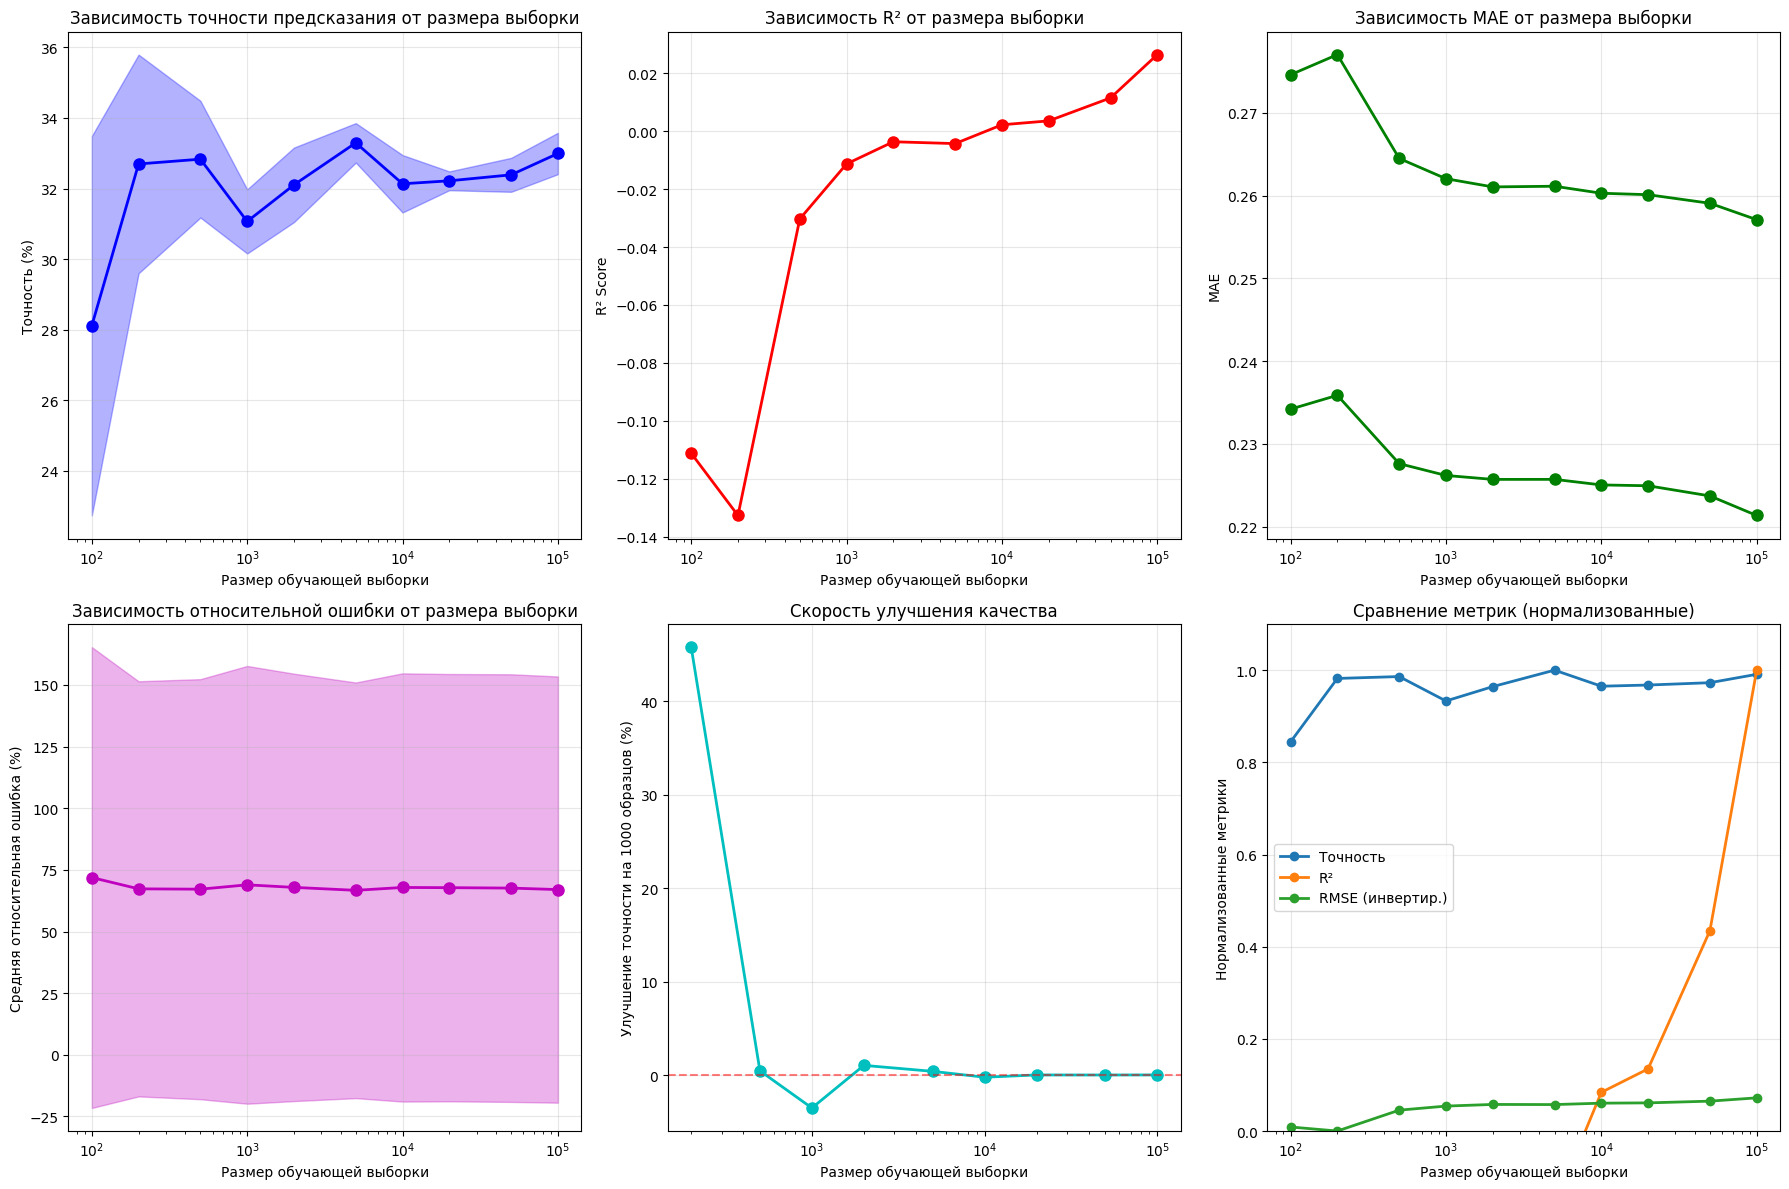

In [8]:

# Визуализация результатов
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Точность предсказания от размера выборки
axes[0, 0].plot(results_df['sample_size'], results_df['accuracy'], 'bo-', linewidth=2, markersize=8)
axes[0, 0].fill_between(results_df['sample_size'], 
                        results_df['accuracy'] - results_df['accuracy_std'],
                        results_df['accuracy'] + results_df['accuracy_std'],
                        alpha=0.3, color='b')
axes[0, 0].set_xlabel('Размер обучающей выборки')
axes[0, 0].set_ylabel('Точность (%)')
axes[0, 0].set_title('Зависимость точности предсказания от размера выборки')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log')

# 2. R² от размера выборки
axes[0, 1].plot(results_df['sample_size'], results_df['r2'], 'ro-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Размер обучающей выборки')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].set_title('Зависимость R² от размера выборки')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xscale('log')

# 3. RMSE от размера выборки
axes[0, 2].plot(results_df['sample_size'], results_df['rmse'], 'go-', linewidth=2, markersize=8)
axes[0, 2].set_xlabel('Размер обучающей выборки')
axes[0, 2].set_ylabel('RMSE')
axes[0, 2].set_title('Зависимость RMSE от размера выборки')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_xscale('log')

# 3.2 MAE от размера выборки
axes[0, 2].plot(results_df['sample_size'], results_df['mae'], 'go-', linewidth=2, markersize=8)
axes[0, 2].set_xlabel('Размер обучающей выборки')
axes[0, 2].set_ylabel('MAE')
axes[0, 2].set_title('Зависимость MAE от размера выборки')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_xscale('log')

# 4. Относительная ошибка от размера выборки
axes[1, 0].plot(results_df['sample_size'], results_df['mean_rel_error'], 'mo-', linewidth=2, markersize=8)
axes[1, 0].fill_between(results_df['sample_size'],
                        results_df['mean_rel_error'] - results_df['std_rel_error'],
                        results_df['mean_rel_error'] + results_df['std_rel_error'],
                        alpha=0.3, color='m')
axes[1, 0].set_xlabel('Размер обучающей выборки')
axes[1, 0].set_ylabel('Средняя относительная ошибка (%)')
axes[1, 0].set_title('Зависимость относительной ошибки от размера выборки')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xscale('log')

# 5. Скорость обучения (время/качество)
improvement = []
for i in range(1, len(results_df)):
    imp = (results_df['accuracy'].iloc[i] - results_df['accuracy'].iloc[i-1]) / \
          (results_df['sample_size'].iloc[i] - results_df['sample_size'].iloc[i-1])
    improvement.append(imp * 1000)  # Умножаем для лучшей визуализации

axes[1, 1].plot(results_df['sample_size'].iloc[1:], improvement, 'co-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Размер обучающей выборки')
axes[1, 1].set_ylabel('Улучшение точности на 1000 образцов (%)')
axes[1, 1].set_title('Скорость улучшения качества')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xscale('log')
axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 6. Сравнение метрик (нормализованные)
metrics_normalized = pd.DataFrame({
    'Точность': results_df['accuracy'] / results_df['accuracy'].max(),
    'R²': results_df['r2'] / results_df['r2'].max(),
    'RMSE (инвертир.)': 1 - results_df['rmse'] / results_df['rmse'].max()
})

for metric in metrics_normalized.columns:
    axes[1, 2].plot(results_df['sample_size'], metrics_normalized[metric], 
                   'o-', linewidth=2, markersize=6, label=metric)

axes[1, 2].set_xlabel('Размер обучающей выборки')
axes[1, 2].set_ylabel('Нормализованные метрики')
axes[1, 2].set_title('Сравнение метрик (нормализованные)')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_xscale('log')
axes[1, 2].legend()
axes[1, 2].set_ylim([0, 1.1])

plt.tight_layout()
plt.show()


In [9]:
results_df

,sample_size,mse,mae,mape,rmse,r2,mean_rel_error,std_rel_error,accuracy,accuracy_std
0,100,0.075450,0.234198,0.718871,0.274600,-0.111206,71.887074,93.449836,28.112926,5.373384
1,200,0.076909,0.235872,0.673049,0.277033,-0.132699,67.304920,84.178667,32.695080,3.097109
2,500,0.069956,0.227615,0.671691,0.264493,-0.030298,67.169134,85.179296,32.830866,1.653844
3,1000,0.068666,0.226186,0.689328,0.262041,-0.011293,68.932769,88.764318,31.067231,0.908214
4,2000,0.068147,0.225711,0.678968,0.261049,-0.003642,67.896758,86.669206,32.103242,1.055652
5,5000,0.068190,0.225714,0.667064,0.261131,-0.004277,66.706450,84.282222,33.293550,0.559025
6,10000,0.067749,0.225042,0.678664,0.260285,0.002219,67.866353,86.831394,32.133647,0.813350
7,20000,0.067657,0.224942,0.677819,0.260109,0.003568,67.781855,86.644109,32.218145,0.266258
8,50000,0.067119,0.223713,0.676126,0.259073,0.011496,67.612576,86.715434,32.387424,0.480933
9,100000,0.066103,0.221350,0.670076,0.257092,0.026450,67.007635,86.421054,32.992365,0.586879
